In [23]:
import os
from dotenv import load_dotenv

# Charge les variables cachées du fichier .env
load_dotenv() 

# La clé est maintenant chargée en mémoire sans être visible dans le code !
print("Clé API chargée depuis le .env !")

Clé API chargée depuis le .env !


In [24]:
# === CONFIGURATION DU PROJET ===
# TODO : renseigner les noms de vos deux classes (en snake_case, sans espace)
CLASS_A = "hot_dog"
CLASS_B = "not_hot_dog"
# TODO : chemin racine où les images brutes seront extraites
DATA_ROOT = "./data"

In [25]:
!kaggle datasets download -d dansbecker/hot-dog-not-hot-dog -p ./raw_data

# Dézippage local
import zipfile

os.makedirs("./raw_data", exist_ok=True)
with zipfile.ZipFile("./raw_data/hot-dog-not-hot-dog.zip", 'r') as zip_ref:
    zip_ref.extractall("./raw_data")
print("Dataset dézippé avec succès")

Dataset URL: https://www.kaggle.com/datasets/dansbecker/hot-dog-not-hot-dog
License(s): other




  0%|          | 0.00/89.3M [00:00<?, ?B/s]
  1%|          | 1.00M/89.3M [00:00<00:45, 2.03MB/s]
  3%|▎         | 3.00M/89.3M [00:00<00:15, 5.78MB/s]
  8%|▊         | 7.00M/89.3M [00:00<00:06, 13.7MB/s]
 13%|█▎        | 12.0M/89.3M [00:00<00:03, 23.0MB/s]
 19%|█▉        | 17.0M/89.3M [00:00<00:02, 30.1MB/s]
 25%|██▍       | 22.0M/89.3M [00:01<00:02, 35.3MB/s]
 30%|███       | 27.0M/89.3M [00:01<00:01, 39.3MB/s]
 36%|███▌      | 32.0M/89.3M [00:01<00:01, 42.3MB/s]
 41%|████▏     | 37.0M/89.3M [00:01<00:01, 44.2MB/s]
 47%|████▋     | 42.0M/89.3M [00:01<00:01, 45.8MB/s]
 53%|█████▎    | 47.0M/89.3M [00:01<00:00, 45.9MB/s]
 59%|█████▉    | 53.0M/89.3M [00:01<00:00, 47.3MB/s]
 65%|██████▍   | 58.0M/89.3M [00:01<00:00, 48.4MB/s]
 71%|███████   | 63.0M/89.3M [00:01<00:00, 48.2MB/s]
 76%|███████▌  | 68.0M/89.3M [00:02<00:00, 48.6MB/s]
 83%|████████▎ | 74.0M/89.3M [00:02<00:00, 48.6MB/s]
 88%|████████▊ | 79.0M/89.3M [00:02<00:00, 49.2MB/s]
 95%|█████████▌| 85.0M/89.3M [00:02<00:00, 48.7MB/s]
1

Dataset dézippé avec succès


In [26]:
import os, shutil, random
import glob

# TODO 1 : lister les fichiers bruts pour CLASS_A et CLASS_B
# (adapter le chemin selon la structure livrée par Kaggle)
files_a = glob.glob("./raw_data/**/hot_dog/*.jpg", recursive=True)
files_b = glob.glob("./raw_data/**/not_hot_dog/*.jpg", recursive=True)

# TODO 2 : créer les dossiers train/CLASS_A, train/CLASS_B, val/CLASS_A, val/CLASS_B
# avec os.makedirs(..., exist_ok=True)
for split in ['train', 'val']:
    for cls in [CLASS_A, CLASS_B]:
        os.makedirs(os.path.join(DATA_ROOT, split, cls), exist_ok=True)

# TODO 3 : mélanger chaque liste (random.shuffle) avec seed=42 pour la reproductibilité
random.seed(42)
random.shuffle(files_a)

random.seed(42)
random.shuffle(files_b)

# TODO 4 : split 80% train / 20% val pour chaque classe et copier avec shutil.copy
def split_and_copy(files, class_name):
    split_idx = int(len(files) * 0.8)
    
    # 80% pour l'entraînement
    for f in files[:split_idx]:
        shutil.copy(f, os.path.join(DATA_ROOT, 'train', class_name))
        
    # 20% pour la validation
    for f in files[split_idx:]:
        shutil.copy(f, os.path.join(DATA_ROOT, 'val', class_name))

# Lancement de la répartition
split_and_copy(files_a, CLASS_A)
split_and_copy(files_b, CLASS_B)

# Vérification : ce bloc doit tourner sans modification
for split in ['train', 'val']:
    for cls in [CLASS_A, CLASS_B]:
        path = os.path.join(DATA_ROOT, split, cls)
        print(f"{path} : {len(os.listdir(path))} images")

./data\train\hot_dog : 482 images
./data\train\not_hot_dog : 482 images
./data\val\hot_dog : 183 images
./data\val\not_hot_dog : 183 images


Shape hot_dog 1 : (512, 512, 3)
Shape hot_dog 2 : (512, 512, 3)
Shape hot_dog 3 : (512, 512, 3)
Shape not_hot_dog 1 : (382, 512, 3)
Shape not_hot_dog 2 : (384, 512, 3)
Shape not_hot_dog 3 : (384, 512, 3)


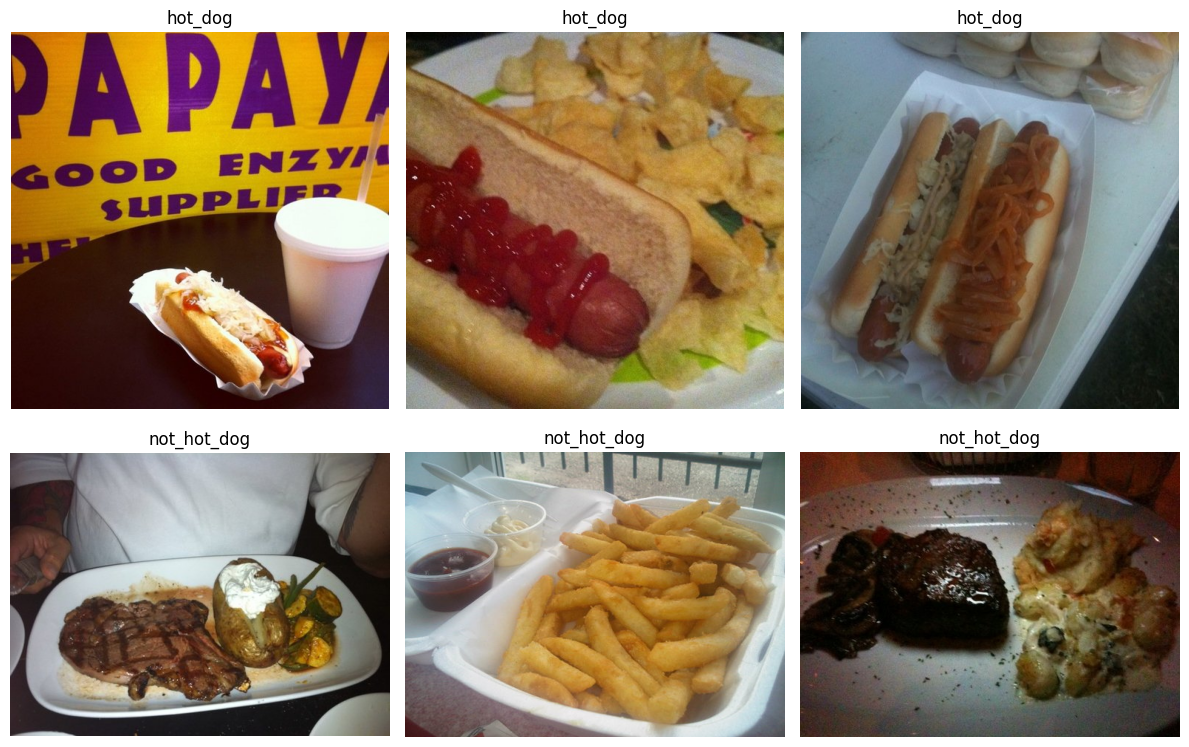

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# TODO : afficher 3 images de CLASS_A et 3 images de CLASS_B côte à côte.
# Structure : plt.subplot(2, 3, i+1), plt.imshow(), plt.title(CLASS_A ou CLASS_B)
# Vérifier que les shapes se terminent par 3 (RGB) ou 1 (niveaux de gris).
plt.figure(figsize=(12, 8))

# Chemins vers images d'entraînement triées
train_dir_a = os.path.join(DATA_ROOT, 'train', CLASS_A)
train_dir_b = os.path.join(DATA_ROOT, 'train', CLASS_B)

# Liste des 3 premières images de chaque classe
images_a = os.listdir(train_dir_a)[:3]
images_b = os.listdir(train_dir_b)[:3]

# Affichage des 3 images de la classe A (hot_dog) sur la première ligne
for i, img_name in enumerate(images_a):
    img_path = os.path.join(train_dir_a, img_name)
    img = mpimg.imread(img_path)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(CLASS_A)
    plt.axis('off')
    print(f"Shape {CLASS_A} {i+1} : {img.shape}")

# Affichage des 3 images de la classe B (not_hot_dog) sur la deuxième ligne
for i, img_name in enumerate(images_b):
    img_path = os.path.join(train_dir_b, img_name)
    img = mpimg.imread(img_path)
    
    plt.subplot(2, 3, i + 4) 
    plt.imshow(img)
    plt.title(CLASS_B)
    plt.axis('off')
    print(f"Shape {CLASS_B} {i+1} : {img.shape}")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
# TODO : choisir la taille de redimensionnement et la taille de batch.
# Conseils : IMG_SIZE entre 64x64 et 160x160 selon la RAM Colab disponible.
# BATCH_SIZE entre 16 et 64 (32 est un bon défaut).
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

# TODO : compléter les paramètres de image_dataset_from_directory pour train_ds.
# Paramètres à renseigner : image_size, batch_size, label_mode, shuffle, seed.
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "train"),
    # TODO : tous les paramètres
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=42
)
# TODO : même chose pour val_ds (shuffle=False pour la reproductibilité).
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "val"),
    # TODO : tous les paramètres
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False, 
    seed=42
)

# TODO : appliquer Rescaling(1./255) sur train_ds et val_ds avec .map().
# normalization_layer = tf.keras.layers.Rescaling(1./255)
normalization_layer = tf.keras.layers.Rescaling(1./255)

# TODO : appliquer .cache().prefetch(buffer_size=AUTOTUNE) sur train_ds.
# et .cache().prefetch(buffer_size=AUTOTUNE) sur val_ds.
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# TODO : afficher la shape du premier batch (images et labels).
# Indice : next(iter(train_ds)) retourne un tuple (images, labels).
# Shape attendue images : (BATCH_SIZE, IMG_SIZE[0], IMG_SIZE[1], 3)
# Shape attendue labels : (BATCH_SIZE, 1)
# Valeurs attendues : entre 0.0 et 1.0 après Rescaling
image_batch, label_batch = next(iter(train_ds))

print("\n--- vérif ---")
print(f"Shape des images attendue : ({BATCH_SIZE}, {IMG_SIZE[0]}, {IMG_SIZE[1]}, 3)")
print(f"Shape des images obtenue  : {image_batch.shape}")
print(f"Shape des labels attendue : ({BATCH_SIZE}, 1)")
print(f"Shape des labels obtenue  : {label_batch.shape}")

min_val = tf.reduce_min(image_batch)
max_val = tf.reduce_max(image_batch)
print(f"Valeurs des pixels : de {min_val:.1f} à {max_val:.1f} (attendu: 0.0 à 1.0)")

Found 964 files belonging to 2 classes.
Found 366 files belonging to 2 classes.

--- VÉRIFICATION DU BATCH ---
Shape des images attendue : (32, 160, 160, 3)
Shape des images obtenue  : (32, 160, 160, 3)
Shape des labels attendue : (32, 1)
Shape des labels obtenue  : (32, 1)
Valeurs des pixels : de 0.0 à 1.0 (attendu: 0.0 à 1.0)


In [35]:
from tensorflow.keras import layers, models

def build_cnn_scratch(input_shape):
    """
    CNN from scratch pour la classification binaire.
    Architecture délibérément simple : on veut voir l'overfitting, pas l'éviter.
    input_shape : tuple (H, W, C) correspondant à votre IMG_SIZE + nombre de canaux
    Retourne : un model Sequential non compilé
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # TODO : bloc 1 - Conv2D(32, (3,3), activation='relu', padding='same',input_shape=input_shape)
        # suivi MaxPooling2D((2,2))
        # Shape en sortie : (H/2, W/2, 32) - calculer avec votre IMG_SIZE
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # TODO : bloc 2 - Conv2D(64, (3,3)) + MaxPooling2D((2,2))
        # Shape en sortie : (H/4, W/4, 64) - calculer avant d'exécuter
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # TODO : bloc 3 - Conv2D(128, (3,3)) + MaxPooling2D((2,2))
        # Shape en sortie : (H/8, W/8, 128) - calculer avant d'exécuter
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # TODO : Flatten()
        # Shape en sortie : (H/8 * W/8 * 128,) - calculer le nombre total d'éléments
        layers.Flatten(),

        # TODO : Dense(128, activation='relu')
        layers.Dense(128, activation='relu'),

        layers.Dense(1, activation='sigmoid')
        ])
    return model

model_scratch = build_cnn_scratch(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
model_scratch.summary()

# TODO : compiler avec optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
model_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)